<a href="https://colab.research.google.com/github/kjahan/nlp_tips_and_trick/blob/main/notebooks/test_docquery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Testing DocQuery

https://huggingface.co/spaces/impira/docquery
https://github.com/impira/docquery


## Step 1
Upload the disclosure pdf to Google Colab

Upload `1950BroadwayStreet.pdf`

In [1]:
!mkdir "/content/disclosures"

## Convert each pdf page to a JPEG

In [1]:
!pip install pdf2image
!apt-get install poppler-utils

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Reading package lists... Done
Building dependency tree       
Reading state information... Done
poppler-utils is already the newest version (0.62.0-2ubuntu2.12).
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'apt autoremove' to remove it.
0 upgraded, 0 newly installed, 0 to remove and 20 not upgraded.


## Imports

In [2]:
import pandas as pd

import math
import re
import string

from os import listdir
from os.path import isfile, join

from pdf2image import convert_from_path

from google.colab import files

## Set Disclosure filename

In [3]:
disclosure_fn = '/content/disclosures/1950BroadwayStreet.pdf'

## Load all pages of the discosure

In [4]:
disclosure_pages = {}
# Only scan the first k pages
top_pages_to_be_converted=30

pages = convert_from_path(disclosure_fn, last_page=top_pages_to_be_converted)

## Diplay first page of one of Disclosures

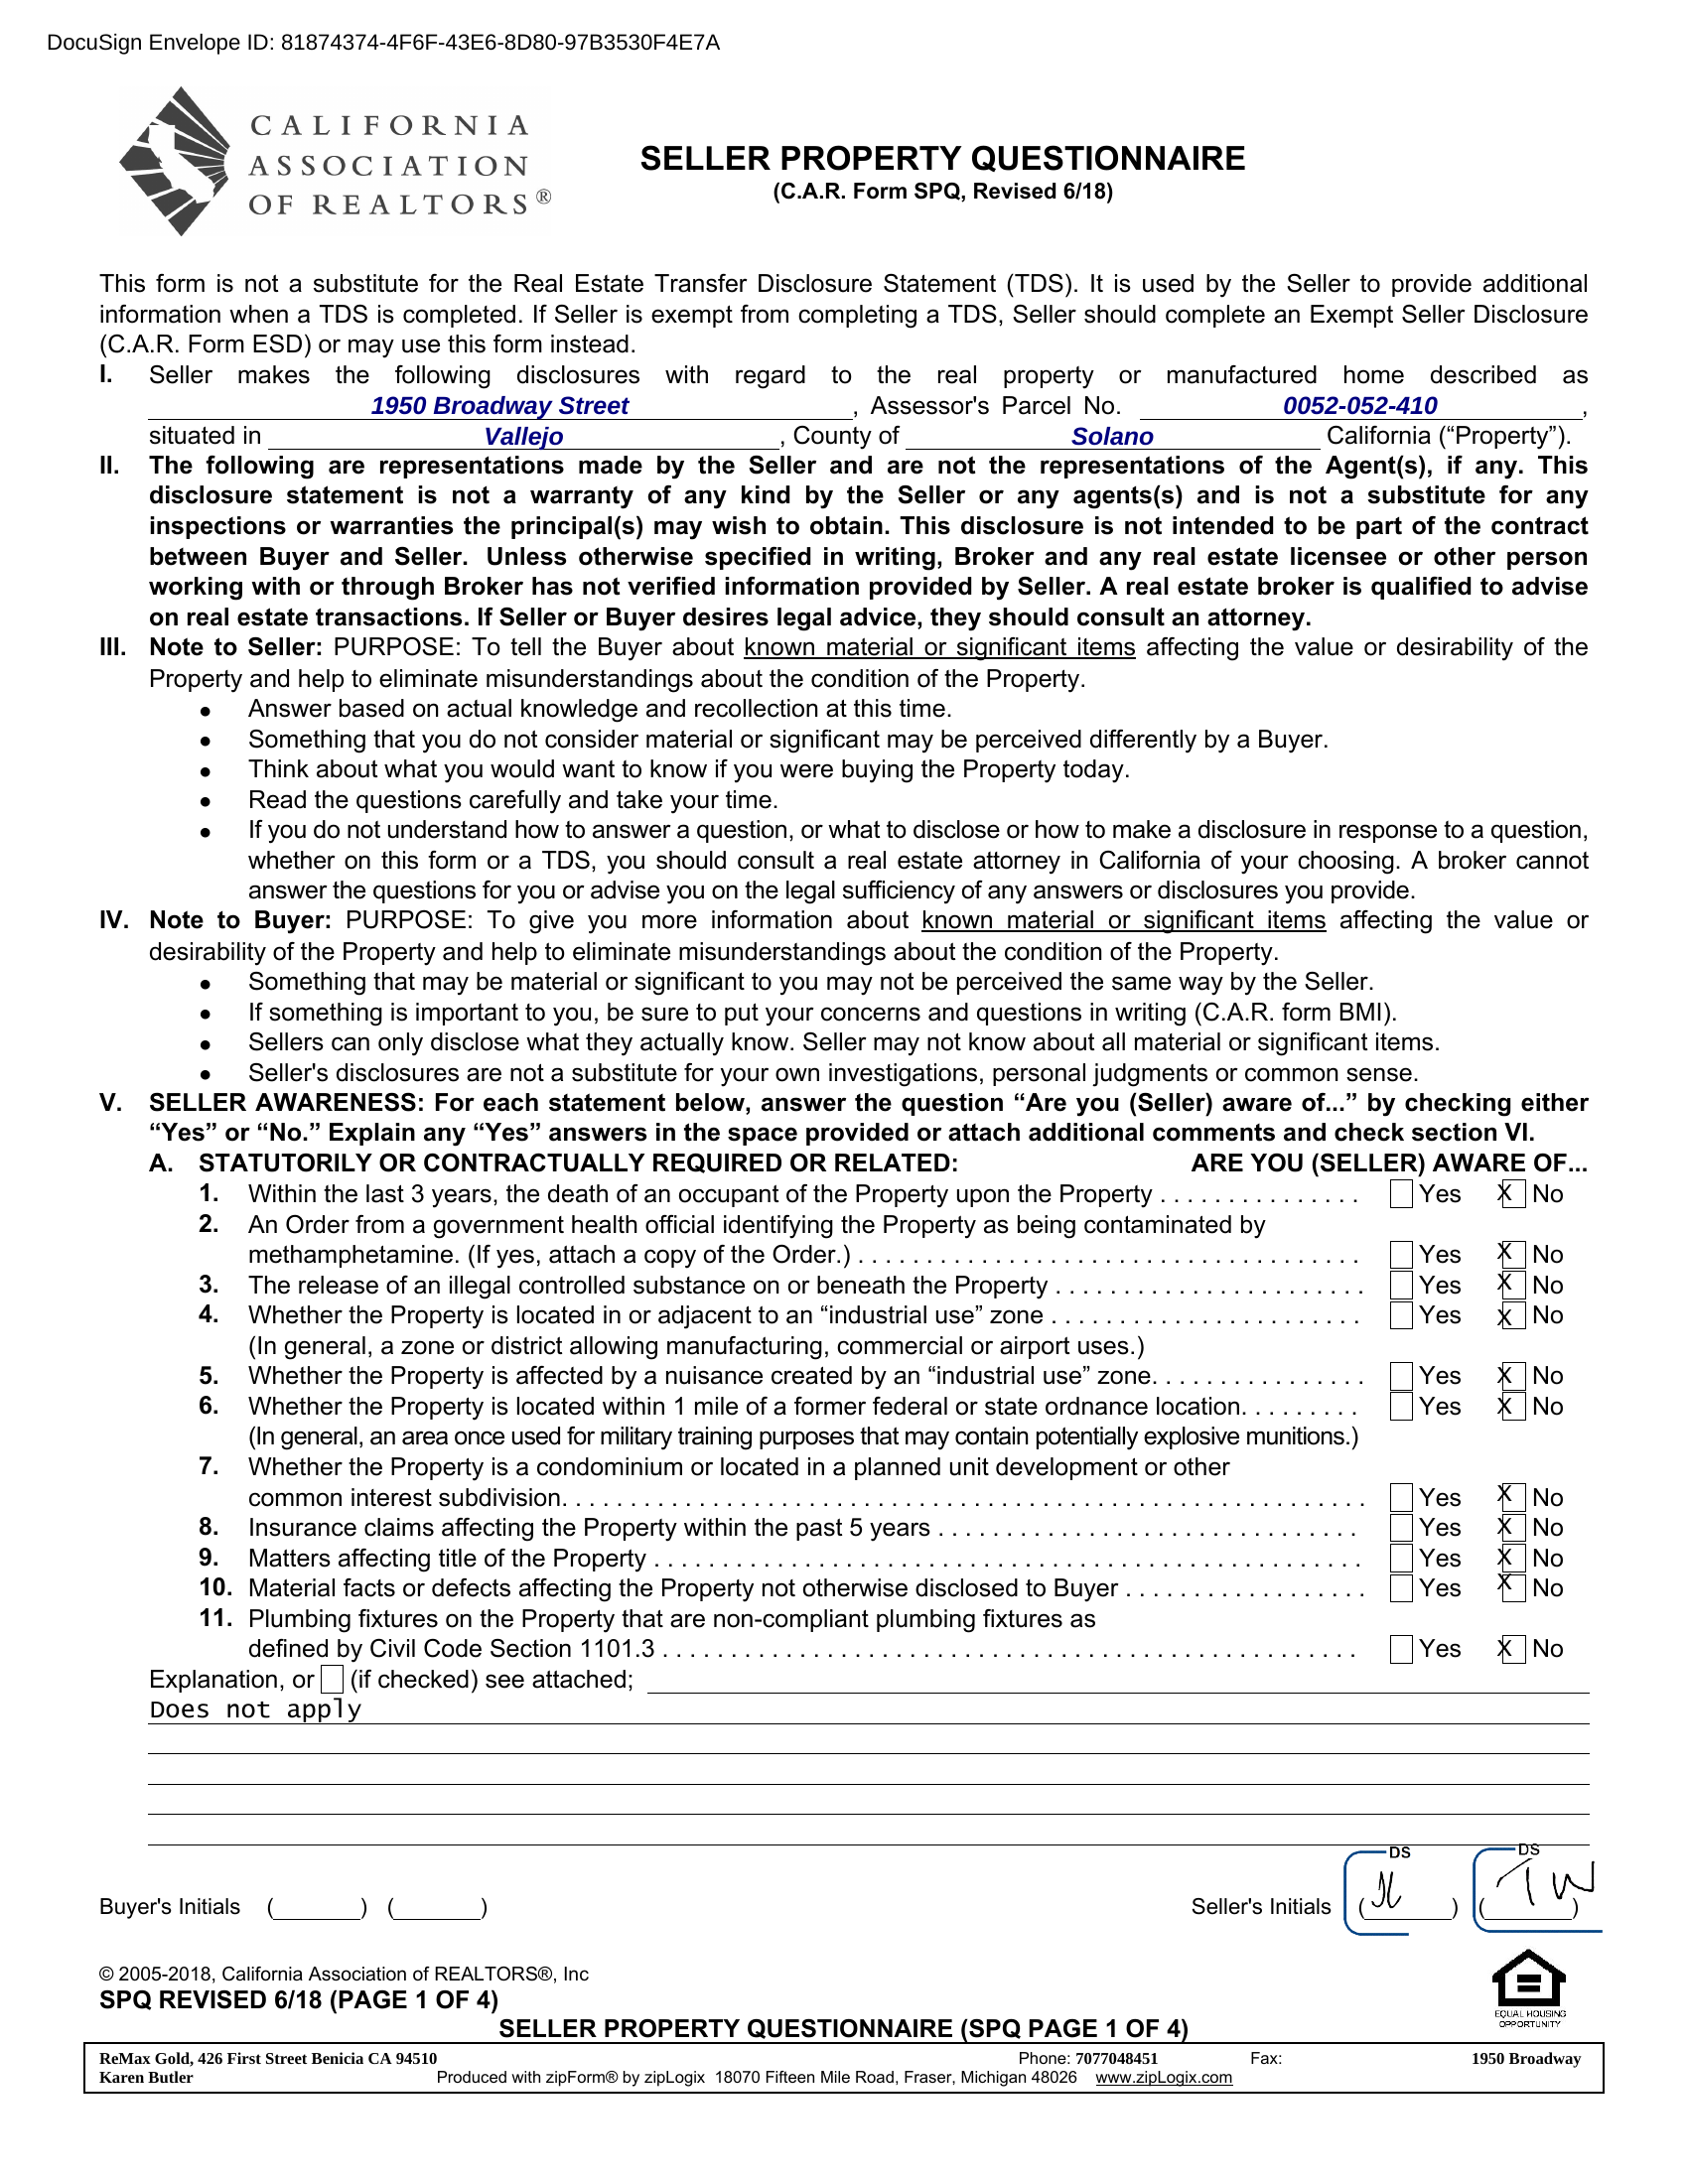

In [5]:
test_inx = 0
pages[test_inx]

## Install tesseract
In the command line on MAC, run this command on Mac fpr tesseract command line:

brew install tesseract

https://pypi.org/project/pytesseract/#history

In [8]:
! apt install tesseract-ocr
! apt install libtesseract-dev
! pip install Pillow
! pip install pytesseract

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'apt autoremove' to remove it.
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 20 not upgraded.
Need to get 4,795 kB of archives.
After this operation, 15.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu bionic/universe amd64 tesseract-ocr-eng all 4.00~git24-0e00fe6-1.2 [1,588 kB]
Get:2 http://archive.ubuntu.com/ubuntu bionic/universe amd64 tesseract-ocr-osd all 4.00~git24-0e00fe6-1.2 [2,989 kB]
Get:3 http://archive.ubuntu.com/ubuntu bionic/universe amd64 tesseract-ocr amd64 4.00~git2288-10f4998a-2 [218 kB]
Fetched 4,795 kB in 2s (2,948 kB/s)
Selecting previously unselect

In [6]:
!pip install docquery

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 4.7 MB 8.6 MB/s 
     |████████████████████████████████| 40 kB 4.6 MB/s 
     |████████████████████████████████| 120 kB 36.7 MB/s 
     |████████████████████████████████| 6.6 MB 47.1 MB/s 
     |████████████████████████████████| 5.6 MB 40.2 MB/s 
     |████████████████████████████████| 142 kB 59.8 MB/s 
     |████████████████████████████████| 4.1 MB 56.4 MB/s 


In [7]:
!docquery scan "What is the effective date?" /content/disclosures/

2022-09-05 00:38:09,725 INFO: Loading /content/disclosures/1950BroadwayStreet.pdf
2022-09-05 00:38:09,726 INFO: Done loading files. Loading pipeline...
2022-09-05 00:38:45,168 INFO: Ready to start evaluating!
/content/disclosures/1950BroadwayStreet.pdf What is the effective date?: 7/15/16


In [8]:
!docquery scan "What is Assessor's Parcel No?" /content/disclosures/

2022-09-05 00:47:53,512 INFO: Loading /content/disclosures/1950BroadwayStreet.pdf
2022-09-05 00:47:53,512 INFO: Done loading files. Loading pipeline...
2022-09-05 00:47:59,933 INFO: Ready to start evaluating!
/content/disclosures/1950BroadwayStreet.pdf What is Assessor's Parcel No?: ASSESSOR'SPARCELNO.0052-052-410


In [9]:
!docquery scan "Is any part of the property being painted within the past 12 months?" /content/disclosures/

2022-09-05 00:52:45,895 INFO: Loading /content/disclosures/1950BroadwayStreet.pdf
2022-09-05 00:52:45,895 INFO: Done loading files. Loading pipeline...
2022-09-05 00:52:51,861 INFO: Ready to start evaluating!
/content/disclosures/1950BroadwayStreet.pdf Is any part of the property being painted within the past 12 months?: 1950


In [10]:
!docquery scan "Was the property built before 1978?" /content/disclosures/

2022-09-05 00:57:42,314 INFO: Loading /content/disclosures/1950BroadwayStreet.pdf
2022-09-05 00:57:42,314 INFO: Done loading files. Loading pipeline...
2022-09-05 00:57:47,802 INFO: Ready to start evaluating!
/content/disclosures/1950BroadwayStreet.pdf Was the property built before 1978?: not
